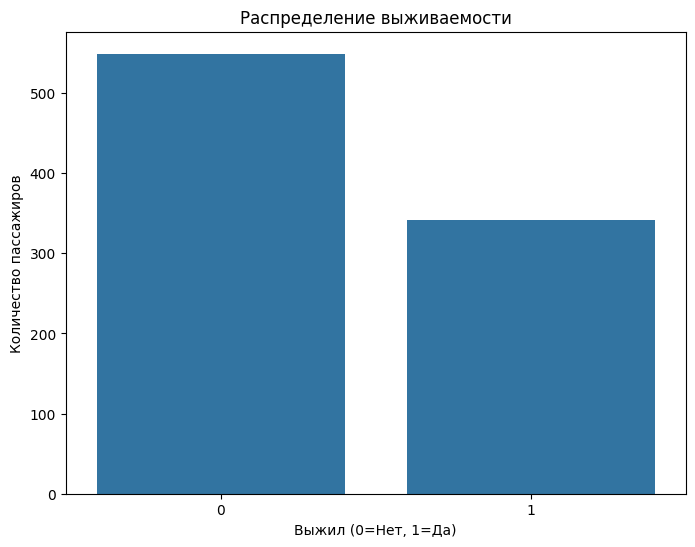

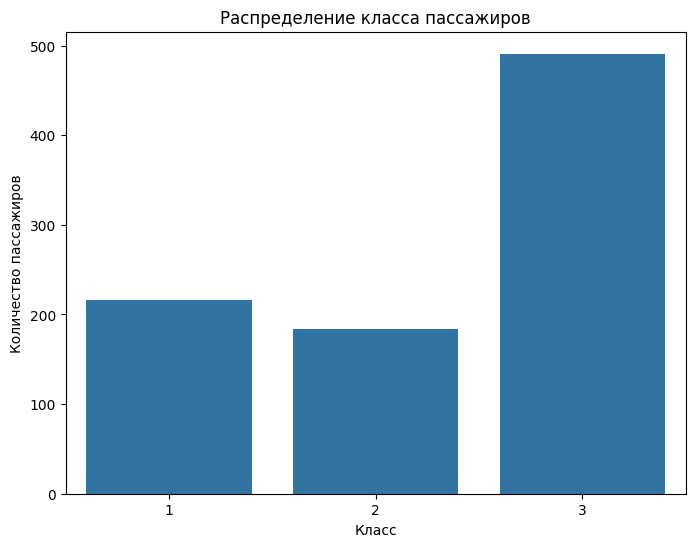

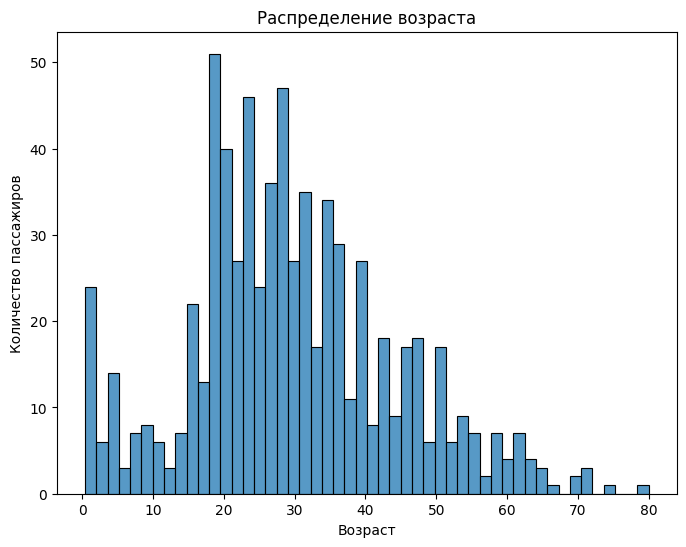

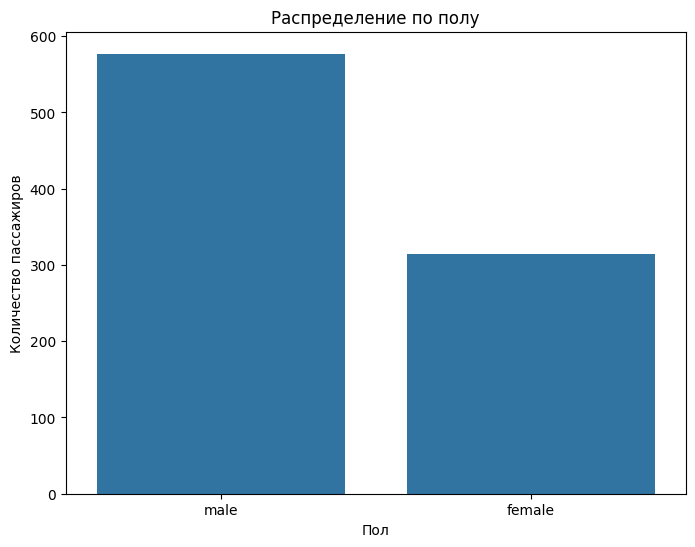

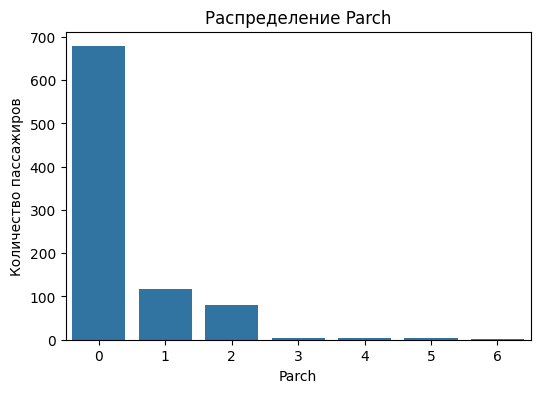

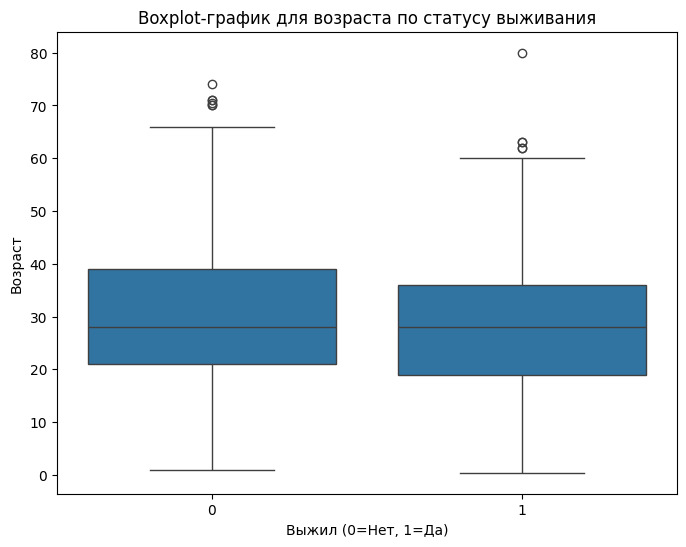

Интерпретация: по графику видно, что выжившие в среднем моложе, чем те, кто не выжил. Также у тех, кто не выжил, больше разброс возрастов, особенно в возрастных группах старше 60 лет.


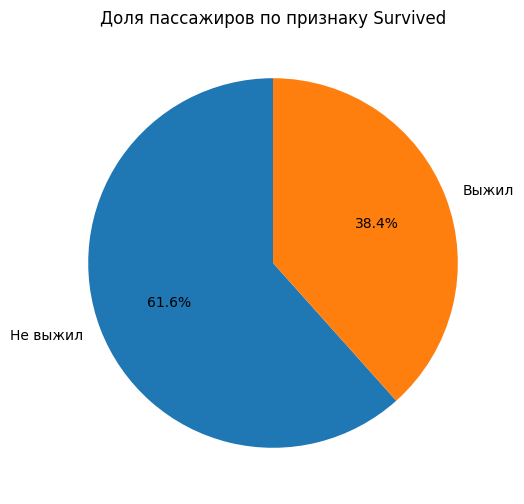

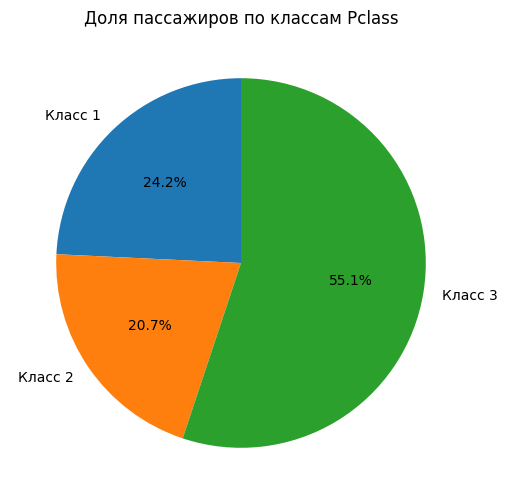

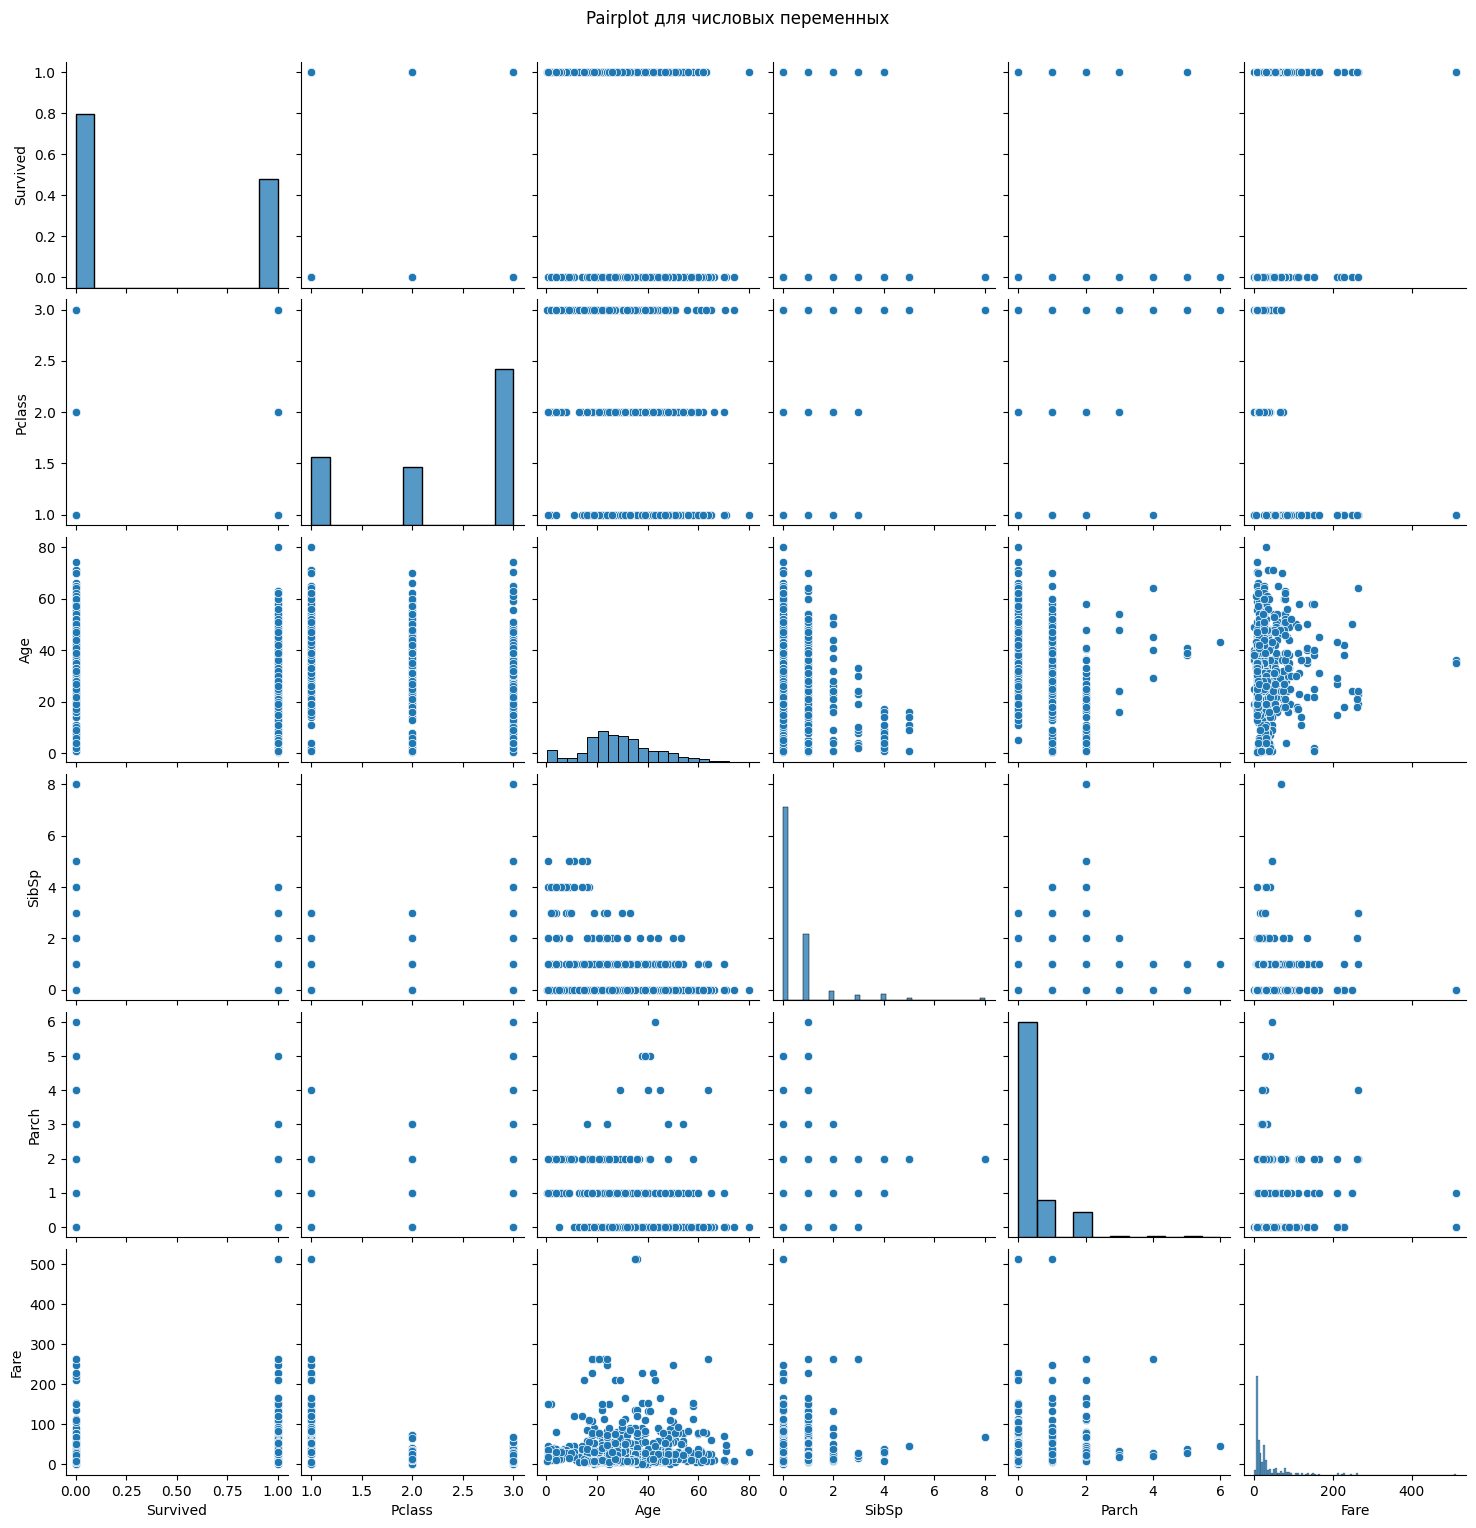

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Считывание из файла train.csv (данные о выживаемости на Титанике)
url='https://raw.githubusercontent.com/AlekPinPin/itmo_python_tasks/refs/heads/main/train.csv'
df_t=pd.read_csv(url)

#print("\nИнформация о датасете:")
#print(df_t.info())

# Визуализация распределение значений признаков Survived, Pclass, Age, Sex. Parch
## Распределение Survived
plt.figure(figsize=(8, 6))
sns.countplot(data=df_t, x='Survived')
plt.title('Распределение выживаемости')
plt.xlabel('Выжил (0=Нет, 1=Да)')
plt.ylabel('Количество пассажиров')
plt.show()

## Распределение Pclass
plt.figure(figsize=(8, 6))
sns.countplot(data=df_t, x='Pclass')
plt.title('Распределение класса пассажиров')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.show()

## Распределение Age
plt.figure(figsize=(8, 6))
sns.histplot(data=df_t, x='Age', bins=50)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.show()

## Распределение Sex
plt.figure(figsize=(8, 6))
sns.countplot(data=df_t, x='Sex')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пассажиров')
plt.show()

## Распределение Parch
plt.figure(figsize=(6, 4))
sns.countplot(data=df_t, x='Parch')
plt.title('Распределение Parch')
plt.xlabel('Parch')
plt.ylabel('Количество пассажиров')
plt.show()

#Построение графика типа boxplot для столбца Age
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df_t)
plt.title('Boxplot-график для возраста по статусу выживания')
plt.xlabel('Выжил (0=Нет, 1=Да)')
plt.ylabel('Возраст')
plt.show()


#Проинтепретируйте полученный график
print("Интерпретация: по графику видно, что выжившие в среднем моложе, чем те, кто не выжил. Также у тех, кто не выжил, больше разброс возрастов, особенно в возрастных группах старше 60 лет.")

#Построение графика типа pie chart для переменных Survived, Pclass, подпишите доли в процентах
## Survived
survived_counts = df_t['Survived'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(survived_counts, labels=['Не выжил', 'Выжил'], autopct='%1.1f%%', startangle=90)
plt.title('Доля пассажиров по признаку Survived')
plt.show()

## Pclass
pclass_counts = df_t['Pclass'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.pie(pclass_counts, labels=['Класс 1', 'Класс 2', 'Класс 3'], autopct='%1.1f%%', startangle=90)
plt.title('Доля пассажиров по классам Pclass')
plt.show()

#Построение графика типа pairplot для всех числовых переменных датасета
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp','Parch','Fare']
sns.pairplot(df_t[numeric_cols])
plt.suptitle('Pairplot для числовых переменных', y=1.02)
plt.show()

#Построение интерактивного sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе
p = df_t.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
fig = px.sunburst(
    p,
    path=['Pclass', 'Sex'],
    values='count',
    title='Sunburst: Количество пассажиров по классам и полу'
)

fig.show()

#Снабдить все построенные графики наименованиями (title), подписями осей, легендами - выполнено. Все графики с подписями =)
